In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt,sqrt,zeros,array,exp
from numpy import linalg
from scipy.integrate import odeint

In [2]:
# implementation of commutators, note that a reshape is necessary since odeint only accepts 1D arrays
def commutator(A,B):
    return np.matmul(A,B)-np.matmul(B,A)

def commutator_reshape(A,B,Nrows):
    A_reshape = np.reshape(A,(Nrows,Nrows))
    B_reshape = np.reshape(B,(Nrows,Nrows))
    return np.matmul(A_reshape,B_reshape)-np.matmul(B_reshape,A_reshape)

def commutator_reshape_coupled(A,B,Nrows):
    A_reshape = np.reshape(A,(2*Nrows,2*Nrows))
    B_reshape = np.reshape(B,(2*Nrows,2*Nrows))
    return np.matmul(A_reshape,B_reshape)-np.matmul(B_reshape,A_reshape)

In [3]:
# computation of deuteron binding energy via diagonalization
def solve_deuteron(V00, V02, V20, V22, Nrows):  
    hbarc = 197.326
    M = 939
    units_factor = hbarc * hbarc / M
    Hmat = zeros([2*Nrows,2*Nrows],float)
    for i in range(Nrows):
        Hmat[i,i] += units_factor * mesh_points[i] * mesh_points[i]
        Hmat[i + Nrows,i + Nrows] += units_factor * mesh_points[i] * mesh_points[i]

        for j in range(Nrows):
            Hmat[i,j] += units_factor * V00[i,j]
            Hmat[i,j + Nrows] += units_factor * V02[i,j]
            Hmat[i + Nrows,j] += units_factor * V20[i,j]
            Hmat[i + Nrows,j + Nrows] += units_factor * V22[i,j]
    
    w, v = linalg.eig(Hmat)
    idx = np.argsort(w)
    w = w[idx]
    return w[0]

In [4]:
# read in files and get reference deuteron energy for unevolved interaction (fitted to experimental value)
potential_index = 2

# potential_index:
# 1: use EFT potential with 100 mesh points
# 2: use EFT potential with 50 mesh points
# 3: use AV18 potential with 200 mesh points
# 4: use AV18 potential with 80 mesh points    

if potential_index == 1:    
    file00 = "VNN_3S1_EFT.dat"
    file02 = "VNN_3SD1_EFT.dat"
    file20 = "VNN_3DS1_EFT.dat"
    file22 = "VNN_3D1_EFT.dat"
elif potential_index == 2: 
    file00 = "VNN_3S1_EFT_coarse.dat"
    file02 = "VNN_3SD1_EFT_coarse.dat"
    file20 = "VNN_3DS1_EFT_coarse.dat"
    file22 = "VNN_3D1_EFT_coarse.dat"
elif potential_index == 3:
    file00 = "VNN_3S1_AV18.dat"
    file02 = "VNN_3SD1_AV18.dat"
    file20 = "VNN_3DS1_AV18.dat"
    file22 = "VNN_3D1_AV18.dat"
elif potential_index == 4:
    file00 = "VNN_3S1_AV18_coarse.dat"
    file02 = "VNN_3SD1_AV18_coarse.dat"
    file20 = "VNN_3DS1_AV18_coarse.dat"
    file22 = "VNN_3D1_AV18_coarse.dat"

Nrows=mesh =np.genfromtxt(file00,dtype=(int),skip_header=0,max_rows=1)

mesh =np.genfromtxt(file00,dtype=(float,float),skip_header=1,max_rows=Nrows)
mesh_weights=mesh[:,0]
mesh_points=mesh[:,1]
mesh_points_coupled=zeros(2*Nrows,float)

Vdata00=np.genfromtxt(file00,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata02=np.genfromtxt(file02,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata20=np.genfromtxt(file20,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)
Vdata22=np.genfromtxt(file22,dtype=(float,float,float),skip_header=Nrows+1,max_rows=Nrows*Nrows)

Vmat00 = zeros([Nrows,Nrows],float)
Vmat02 = zeros([Nrows,Nrows],float)
Vmat20 = zeros([Nrows,Nrows],float)
Vmat22 = zeros([Nrows,Nrows],float)
Vmat = zeros([2*Nrows,2*Nrows],float)

Tmat = zeros([Nrows,Nrows],float)
Tmat_coupled = zeros([2*Nrows,2*Nrows],float)
PhaseSpace = zeros([Nrows,Nrows],float)
PhaseSpace_coupled = zeros([2*Nrows,2*Nrows],float)

for i in range(Nrows):
    Tmat[i,i] = mesh_points[i] * mesh_points[i]
    Tmat_coupled[i,i] = Tmat[i,i]
    Tmat_coupled[i+Nrows,i+Nrows] = Tmat[i,i]
    
    for j in range(Nrows):
        Vmat00[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata00[i*Nrows+j][2]
        Vmat02[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata02[i*Nrows+j][2]
        Vmat20[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata20[i*Nrows+j][2]
        Vmat22[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j] * Vdata22[i*Nrows+j][2]
        Vmat[i,j] = Vmat00[i,j]
        Vmat[i,j+Nrows] = Vmat02[i,j]
        Vmat[i+Nrows,j] = Vmat20[i,j]
        Vmat[i+Nrows,j+Nrows] = Vmat22[i,j]
        PhaseSpace[i,j] = 2.0/np.pi*sqrt(mesh_weights[i]) * sqrt(mesh_weights[j]) * mesh_points[i] * mesh_points[j]
        PhaseSpace_coupled[i,j] = PhaseSpace[i,j]
        PhaseSpace_coupled[i,j + Nrows] = PhaseSpace[i,j]
        PhaseSpace_coupled[i + Nrows,j] = PhaseSpace[i,j]
        PhaseSpace_coupled[i + Nrows,j + Nrows] = PhaseSpace[i,j]
             
Edeut = solve_deuteron(Vmat00, Vmat02, Vmat20, Vmat22, Nrows);
print("E_gs = %.6f MeV" % Edeut)

E_gs = -2.224363 MeV


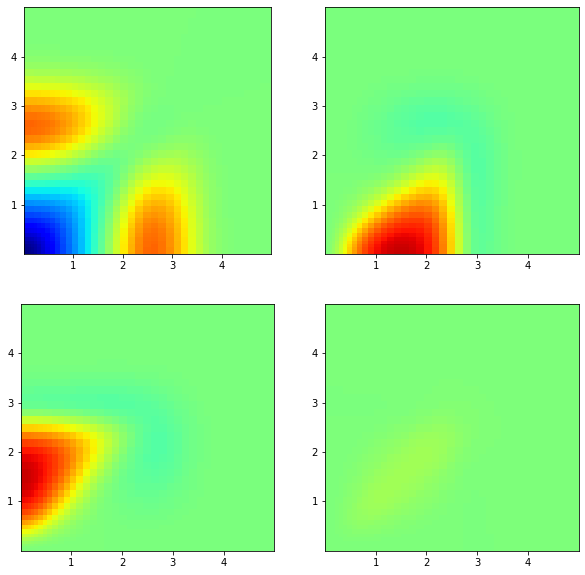

In [5]:
# plot initial matrix elements in coupled channels
maxindex = Nrows
fig, (ax) = plt.subplots(nrows=2,ncols=2,figsize=(10, 10))
maxabs = max(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].min()),abs(abs((Vmat/PhaseSpace_coupled)[:maxindex,:maxindex].max())))
ax[0,0].set_aspect('equal')
im = ax[0,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat00/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[0,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat02/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,0].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat20/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)
im = ax[1,1].pcolormesh(mesh_points[:maxindex], mesh_points[:maxindex], (Vmat22/PhaseSpace)[:maxindex,:maxindex], vmin = -maxabs, vmax = maxabs, cmap='jet',rasterized=True)